# 1. Bradley-Terry Model with Home Court Advantage

### Imports

In [65]:
import pandas as pd
import numpy as np
import json
from typing import Dict, List, Tuple, Optional
from datetime import datetime

import choix
from scipy.special import expit
from scipy.optimize import minimize

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, average_precision_score,brier_score_loss, precision_recall_fscore_support, confusion_matrix, precision_score, ConfusionMatrixDisplay,f1_score,recall_score
import seaborn as sns
from scipy.stats import norm
from scipy.stats import beta as beta_dist
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from skopt import gp_minimize
from skopt.plots import plot_convergence, plot_objective
from skopt.space import Real
from skopt.utils import use_named_args
import plotly.express as px
import plotly.graph_objects as go

### Bradley–Terry Model with HCA & Covariates

In [54]:
class BTWithCovariates:
    def __init__(
        self,
        teams, team_to_idx,
        s, beta,
        feature_cols, mu, sd,
        context_cols=None, gamma=None,
        mu_context=None, sd_context=None,
        lambda_s=1e-3, lambda_b=1e-3, lambda_g=1e-3,
        threshold=0.5,alpha_hca=None
    ):
        # --- core team parameters ---
        self.teams = list(teams)
        self.team_to_idx = dict(team_to_idx)
        self.s = np.array(s, dtype=float)
        self.s -= self.s.mean()  # mean‑centering for identifiability
        self.alpha_hca = 0.1 if alpha_hca is None else float(alpha_hca)

        # --- feature-related parameters X@beta ---
        self.feature_cols = list(feature_cols)
        self.beta = np.array(beta, dtype=float)
        self.mu = np.array(mu, dtype=float)
        self.sd = np.array(sd, dtype=float)
        self.sd[self.sd == 0] = 1.0

        # --- contextual HCA parameters Z@gamma ---
        self.context_cols = list(context_cols) if context_cols else []
        self.gamma = (
            np.random.normal(0, 0.01, len(self.context_cols))
            if gamma is None
            else np.array(gamma, dtype=float)
        )
        self.mu_context = (
            np.zeros(len(self.context_cols))
            if mu_context is None
            else np.array(mu_context, dtype=float)
        )
        self.sd_context = (
            np.ones(len(self.context_cols))
            if sd_context is None
            else np.array(sd_context, dtype=float)
        )
        self.sd_context[self.sd_context == 0] = 1.0

        # learning configuration
        self.lambda_s, self.lambda_b, self.lambda_g = lambda_s, lambda_b, lambda_g
        self.threshold = threshold

    # ---------------- Properties ----------------
    @property
    def m(self): return len(self.teams)
    @property
    def p(self): return len(self.feature_cols)
    @property
    def q(self): return len(self.context_cols)

    # ---------------- Utilities ----------------
    def _ensure_teams(self, df: pd.DataFrame):
        """Ensure unseen teams get added dynamically."""
        unseen = [t for t in pd.unique(df[["home_abbr", "away_abbr"]].values.ravel())
                  if t not in self.team_to_idx]
        if not unseen:
            return
        start = len(self.teams)
        for k, t in enumerate(unseen):
            self.team_to_idx[t] = start + k
        self.teams.extend(unseen)
        # Expand s for new teams (neutral start)
        self.s = np.concatenate([self.s, np.zeros(len(unseen))])
        self.s -= self.s.mean()

    def _standardize(self, arr, mu, sd):
        return (arr - mu) / (sd if sd != 0 else 1.0)

    def _standardize_features(self, frame):
        if self.p == 0:
            return np.zeros((len(frame), 0))
        X = np.zeros((len(frame), self.p))
        for j, col in enumerate(self.feature_cols):
            X[:, j] = self._standardize(frame[col].astype(float).values, self.mu[j], self.sd[j])
        return X

    def _standardize_context(self, frame):
        if self.q == 0:
            return np.zeros((len(frame), 0))
        Z = np.zeros((len(frame), self.q))
        for j, col in enumerate(self.context_cols):
            Z[:, j] = self._standardize(
                frame[col].astype(float).values, self.mu_context[j], self.sd_context[j]
            )
        return Z

    # ---------------- Prediction ----------------
    def predict_proba(self, frame: pd.DataFrame) -> np.ndarray:
        sh = np.array([self.s[self.team_to_idx.get(t, -1)] for t in frame["home_abbr"]])
        sa = np.array([self.s[self.team_to_idx.get(t, -1)] for t in frame["away_abbr"]])

        z = (sh - sa) + self.alpha_hca

        if self.q:
            Z = self._standardize_context(frame)
            z += Z @ self.gamma
        if self.p:
            X = self._standardize_features(frame)
            z += X @ self.beta

        # apply sigmoid
        p = 1.0 / (1.0 + np.exp(-z))
        return p

    def predict_class(self, frame: pd.DataFrame, threshold=None) -> np.ndarray:
        threshold = self.threshold if threshold is None else threshold
        return (self.predict_proba(frame) >= threshold).astype(int)

    # ---------------- Evaluation ----------------
    def evaluate(self, frame: pd.DataFrame, threshold=None):
        threshold = self.threshold if threshold is None else threshold
        p = self.predict_proba(frame)
        y_true = frame["home_win"].astype(int).values
        yhat = (p >= threshold).astype(int)
        acc = (yhat == y_true).mean()
        logloss = -(y_true * np.log(p + 1e-12)
                    + (1 - y_true) * np.log(1 - p + 1e-12)).mean()
        return acc, logloss


    def _mm_update_s(self, home_idx, away_idx, y, X, Z, beta, gamma, mm_iter=5):
            """Perform MM updates for team strengths s while holding beta,gamma fixed."""
            m = self.m
            s = self.s.copy()
            for _ in range(mm_iter):
                exp_s = np.exp(s)
                num = np.zeros(m)
                denom = np.zeros(m)

                for i in range(len(y)):
                    h, a = home_idx[i], away_idx[i]
                    eta = 0.0
                    if X.shape[1]:
                        eta += X[i] @ beta
                    if Z.shape[1]:
                        eta += Z[i] @ gamma
                    p_hat = 1.0 / (1.0 + np.exp(-(s[h] - s[a] + eta)))

                    # Accumulate numerators/denominators
                    num[h] += y[i]
                    num[a] += 1.0 - y[i]
                    denom[h] += p_hat
                    denom[a] += 1.0 - p_hat

                s = np.log((num + 1e-12) / (denom + 1e-12))
                s -= s.mean()   # identifiability
            return s

    def fit(self, df, split_col=None, split_value=None,
            valid_frame=None, test_frame=None, max_iter=1000,
            mm_iter=5, verbose=1):

        data = df if split_col is None else df[df[split_col] == split_value]
        if len(data) == 0:
            raise ValueError("Empty training data.")

        self._ensure_teams(data)

        home_idx = np.array([self.team_to_idx[t] for t in data["home_abbr"]], int)
        away_idx = np.array([self.team_to_idx[t] for t in data["away_abbr"]], int)
        y = data["home_win"].astype(float).values
        X = self._standardize_features(data)
        Z = self._standardize_context(data)
        m, p, q = self.m, self.p, self.q

        # ---------- Step 1: MM update for s (given current beta,gamma) ----------
        if verbose:
            print(f"Running {mm_iter} MM iterations for initial team strength update...")
        self.s = self._mm_update_s(home_idx, away_idx, y, X, Z,
                                   self.beta.copy(), self.gamma.copy(),
                                   mm_iter=mm_iter)

        # ---------- Step 2: Define joint objective for L‑BFGS ----------
        def objective(x):
            s = x[:m]; b = x[m:m+p]; g = x[m+p:m+p+q]; a = x[-1]
            z = (s[home_idx] - s[away_idx]) + a
            if p: z += X @ b
            if q: z += Z @ g
            p_hat = 1 / (1 + np.exp(-z))
            nll = -np.sum(y * np.log(p_hat + 1e-12) +
                          (1 - y) * np.log(1 - p_hat + 1e-12))
            reg = 0.5 * (self.lambda_s*np.sum(s**2)
                         + self.lambda_b*np.sum(b**2)
                         + self.lambda_g*np.sum(g**2)
                         + 1e-4 * a**2)
            loss = nll + reg

            err = y - p_hat
            grad_s = np.zeros_like(s)
            np.add.at(grad_s, home_idx, -err)
            np.add.at(grad_s, away_idx, err)
            grad_b = -(X.T @ err) if p else np.zeros(0)
            grad_g = -(Z.T @ err) if q else np.zeros(0)
            grad_a = -np.sum(err) + 1e-4*a
            grad = np.concatenate([grad_s, grad_b, grad_g, [grad_a]])
            return loss, grad

        # ---------- Step 3: History tracking ----------
        history = {"iter": [], "train_acc": [], "train_logloss": [],
                   "test_acc": [],  "test_logloss": []}

        def callback(xk):
            if verbose is None:
                return
            it = len(history["iter"])
            if it % verbose == 0:
                self.s = xk[:m]
                self.beta = xk[m:m+p]
                self.gamma = xk[m+p:m+p+q]
                self.s -= self.s.mean()
                tr_acc, tr_ll = self.evaluate(data)
                te_acc, te_ll = (np.nan, np.nan)
                if test_frame is not None:
                    te_acc, te_ll = self.evaluate(test_frame)
                history["iter"].append(it)
                history["train_acc"].append(tr_acc)
                history["train_logloss"].append(tr_ll)
                history["test_acc"].append(te_acc)
                history["test_logloss"].append(te_ll)
                print(f"[{it:04d}] Train acc={tr_acc:.4f} ll={tr_ll:.4f} | "
                      f"Test acc={te_acc:.4f} ll={te_ll:.4f}")

        # ---------- L‑BFGS Optimization ----------
        x0 = np.concatenate([self.s, self.beta, self.gamma, [self.alpha_hca]])
        res = minimize(
            objective, x0, jac=True, method="L-BFGS-B",
            callback=callback,
            options={"disp": True, "maxiter": max_iter}
        )

        # ---------- Post‑process ----------
        opt = res.x
        self.s = opt[:m]
        self.beta = opt[m:m+p]
        self.gamma = opt[m+p:m+p+q]
        self.alpha_hca = opt[-1]
        self.s -= self.s.mean()

        tr_acc, tr_ll = self.evaluate(data)
        te_acc, te_ll = (np.nan, np.nan)
        if test_frame is not None:
            te_acc, te_ll = self.evaluate(test_frame)

        history["iter"].append(len(history["iter"]))
        history["train_acc"].append(tr_acc)
        history["train_logloss"].append(tr_ll)
        history["test_acc"].append(te_acc)
        history["test_logloss"].append(te_ll)

        avg_theta = np.exp(self.alpha_hca + np.mean(Z @ self.gamma))
        print(f"Estimated global home‑court multiplier θ̄ = {avg_theta:.4f}")
        if verbose:
            print(f"Final: Train acc={tr_acc:.4f}, logloss={tr_ll:.4f}")

        return {"opt_result": res, "history": history}

### Load and Save Model

In [55]:
def save_model(
    model,
    path_npz: str,
    path_json: Optional[str] = None,
    extra_meta: Optional[Dict] = None,
):
    """
    Save a trained BTWithCovariates model to a compressed .npz file.
    Optionally dump a human-readable JSON alongside it.

    Parameters
    ----------
    model : BTWithCovariates
        Trained model instance.
    path_npz : str
        Path to the output compressed NumPy file (.npz).
    path_json : str, optional
        Path to a JSON file for human-readable parameters.
    extra_meta : dict, optional
        Extra information to store in metadata.
    """
    # --- Prepare metadata ---
    meta = {
        "feature_cols": model.feature_cols,
        "teams": model.teams,
        "extra_meta": extra_meta or {},
        "class_name": model.__class__.__name__,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "optimizer_settings": {
            "lambda_s": model.lambda_s, "lambda_b": model.lambda_b,"threshold": model.threshold,
        },
    }

    # --- Save the model core parameters ---
    np.savez_compressed(
        path_npz,
        s=np.array(model.s, dtype=float),
        beta=np.array(model.beta, dtype=float),
        mu=np.array(model.mu, dtype=float),
        sd=np.array(model.sd, dtype=float),
        teams=np.array(model.teams, dtype=object),
        t2i_keys=np.array(list(model.team_to_idx.keys()), dtype=object),
        t2i_vals=np.array(list(model.team_to_idx.values()), dtype=int),
        gamma=np.array(getattr(model, "gamma", []), dtype=float),
        mu_context=np.array(getattr(model, "mu_context", []), dtype=float),
        sd_context=np.array(getattr(model, "sd_context", []), dtype=float),
        context_cols=np.array(getattr(model, "context_cols", []), dtype=object),
        meta_json=np.bytes_(json.dumps(meta)),
    )

    # --- Optional JSON dump for readability ---
    if path_json:
        payload = {
            "s": model.s.tolist(),
            "beta": model.beta.tolist(),
            "mu": np.array(model.mu).tolist(),
            "sd": np.array(model.sd).tolist(),
            "teams": model.teams,
            "team_to_idx": model.team_to_idx,
            "extra_meta": meta["extra_meta"],
            "optimizer_settings": meta["optimizer_settings"],
            "timestamp": meta["timestamp"],
        }
        with open(path_json, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)
        print(f"Model parameters saved to {path_json}")

    print(f"Model saved successfully to {path_npz}")

def load_model(path_npz: str) -> BTWithCovariates:
    """
    Load a saved BTWithCovariates model (.npz) and reconstruct it
    ready for predictions or continued training on a new dataset.
    """
    # --- Load the compressed file ---
    blob = np.load(path_npz, allow_pickle=True)

    # --- Basic parameters ---
    s = blob["s"].astype(float)

    beta = blob["beta"].astype(float)
    mu = blob["mu"].astype(float)
    sd = blob["sd"].astype(float)
    teams = list(blob["teams"])
    t2i_keys = list(blob["t2i_keys"])
    t2i_vals = list(blob["t2i_vals"])
    team_to_idx = {k: int(v) for k, v in zip(t2i_keys, t2i_vals)}

    # --- Retrieve metadata ---
    meta_raw = blob["meta_json"].tobytes().decode("utf-8")
    meta = json.loads(meta_raw)
    feature_cols = meta.get("feature_cols", [])
    optimizer_settings = meta.get("optimizer_settings", {})

    # --- Restore training hyperparameters safely ---
    lambda_s = float(optimizer_settings.get("lambda_s", 0.002))
    lambda_b = float(optimizer_settings.get("lambda_b", 0.01))
    threshold = float(optimizer_settings.get("threshold", 0.5))
    decay_every = optimizer_settings.get("decay_every", None)
    decay_factor = optimizer_settings.get("decay_factor", None)
    gamma = blob.get("gamma")
    if gamma is not None: gamma = gamma.astype(float)
    mu_context = blob.get("mu_context")
    if mu_context is not None: mu_context = mu_context.astype(float)
    sd_context = blob.get("sd_context")
    if sd_context is not None: sd_context = sd_context.astype(float)
    context_cols = list(blob.get("context_cols", []))

    # --- Recreate model instance ---
    model = BTWithCovariates(
        teams=teams,
        team_to_idx=team_to_idx,
        s=s,
        beta=beta,
        feature_cols=feature_cols,
        mu=mu,
        sd=sd,
        lambda_s=lambda_s,
        lambda_b=lambda_b,
        threshold=threshold,
        gamma=gamma,
        context_cols=context_cols,
        mu_context=mu_context,
        sd_context=sd_context,
    )

    print(f"Model loaded successfully from {path_npz}")
    print(f"Teams: {len(teams)} | Features: {len(feature_cols)}")

    return model

### 1.2 Load Data & Initialization

In [71]:
df = pd.read_csv('./data/bt_games_cleaned.csv')

context_cols = ["home_b2b", "away_b2b","home_rest_days", "away_rest_days", "rest_diff"]
feature_cols = ["diff_recent_margin","diff_recent_win_pct","diff_pts_pg_to_date","split_win_pct_delta"]

# Ensure required columns exist
required = {"home_abbr", "away_abbr", "home_win"}

train=df[df["split"]=="train"].copy()
test=df[df["split"]=="test"].copy()



### 1.3 Build Train Tensors

In [72]:
# Extract indices
teams = sorted(pd.unique(pd.concat([train["home_abbr"], train["away_abbr"]], ignore_index=True)))
team_to_idx = {t: i for i, t in enumerate(teams)}
m = len(teams)

home_idx = np.array([team_to_idx[t] for t in train["home_abbr"]], dtype=int)
away_idx = np.array([team_to_idx[t] for t in train["away_abbr"]], dtype=int)
y = train["home_win"].astype(float).values
n = len(y)

# Standardize regular feature columns (X)
if feature_cols:
    X_raw = train[feature_cols].astype(float).values
    mu = X_raw.mean(axis=0)
    sd = X_raw.std(axis=0)
    sd[sd == 0] = 1.0
    X = (X_raw - mu) / sd
else:
    X = np.zeros((n, 0))
    mu = np.array([])
    sd = np.array([])
p = X.shape[1]

# Standardize contextual columns (Z)
if context_cols:
    Z_raw = train[context_cols].astype(float).values
    mu_context = Z_raw.mean(axis=0)
    sd_context = Z_raw.std(axis=0)
    sd_context[sd_context == 0] = 1.0
    Z = (Z_raw - mu_context) / sd_context
else:
    Z = np.zeros((n, 0))
    mu_context = np.array([])
    sd_context = np.array([])
q = Z.shape[1]

In [58]:
s_init     = np.zeros(len(teams))
beta_init  = np.zeros(len(feature_cols))
gamma_init = np.zeros(len(context_cols))

## 1.A Train and Test

### 1.4 Model Fitting

In [110]:
# After creating df with split in {"train","test","valid"} and computing mu/sd on TRAIN
model = BTWithCovariates(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init,
    beta=beta_init,
    feature_cols=feature_cols,
    mu=mu, sd=sd,
    context_cols=context_cols,
    gamma=gamma_init,
    mu_context=mu_context, sd_context=sd_context,
    lambda_s=1e-3, lambda_b=1e-3, lambda_g=1e-3
)

result = model.fit(
    df,
    split_col="split",
    split_value="train",
    max_iter=10000,
    test_frame=test,
    verbose=1
)

# Final metrics (you can also recompute)
tr_acc,tr_ll = model.evaluate(train)
t_acc, t_ll = model.evaluate(test)
print(f"Train Metric -> acc={tr_acc:.6f} ll={tr_ll:.6f}")
print(f"Test Metric -> acc={t_acc:.6f} ll={t_ll:.6f}")

Running 5 MM iterations for initial team strength update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_26692\39330441.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6270 ll=0.6816
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6329 ll=0.6826
[0002] Train acc=0.6424 ll=0.6309 | Test acc=0.6409 ll=0.6831
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6429 ll=0.6840
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6329 ll=0.6853
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6250 ll=0.6859
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6190 ll=0.6900
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6250 ll=0.6877
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6230 ll=0.6874
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6230 ll=0.6874
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6270 ll=0.6875
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6270 ll=0.6876
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6270 ll=0.6875
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6250 ll=0.6876
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6250 ll=0.6876
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6250 ll=0.6875
[0016] T

### 1.5 Result Evaluation

In [61]:
def evaluate_metrics(model, frame, threshold=0.5, eps=1e-12):
    y_true = frame["home_win"].astype(int).values
    p = model.predict_proba(frame)

    # Core metrics
    acc = accuracy_score(y_true, (p >= threshold).astype(int))
    ll = log_loss(y_true, np.clip(p, eps, 1 - eps))
    brier = brier_score_loss(y_true, p)

    # Ranking metrics (guard against edge cases)
    auc = roc_auc_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan
    ap = average_precision_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan

    # Threshold metrics
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, (p >= threshold).astype(int), average="binary", zero_division=0
    )
    tn, fp, fn, tp = confusion_matrix(y_true, (p >= threshold).astype(int)).ravel()

    return {
        "n": int(len(y_true)),
        "accuracy": float(acc),
        "log_loss": float(ll),
        "brier": float(brier),
        "roc_auc": float(auc),
        "avg_precision": float(ap),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

In [111]:
train_metrics = evaluate_metrics(model, train)
test_metrics  = evaluate_metrics(model, test)

print("Train metrics:")
for k, v in train_metrics.items():
    print(f"  {k}: {v}")

print("Test metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v}")

Train metrics:
  n: 14620
  accuracy: 0.6411764705882353
  log_loss: 0.6406325041673263
  brier: 0.22137641342741113
  roc_auc: 0.6818022950305319
  avg_precision: 0.7257806055638357
  precision: 0.654020328066821
  recall: 0.7823522330564584
  f1: 0.712453409340057
  tn: 2875
  fp: 3438
  fn: 1808
  tp: 6499
Test metrics:
  n: 504
  accuracy: 0.6468253968253969
  log_loss: 0.6815858002929656
  brier: 0.22237072321815954
  roc_auc: 0.6781579665697908
  avg_precision: 0.7227217695854599
  precision: 0.6617210682492581
  recall: 0.7770034843205574
  f1: 0.7147435897435898
  tn: 103
  fp: 114
  fn: 64
  tp: 223


### 1.6 Plots

In [112]:
hist = result["history"]

# convert arrays safely
iters     = np.array(hist["iter"], dtype=float)
train_acc = np.array(hist["train_acc"], dtype=float)
test_acc  = np.array(hist["test_acc"], dtype=float)
train_ll  = np.array(hist["train_logloss"], dtype=float)
test_ll   = np.array(hist["test_logloss"], dtype=float)

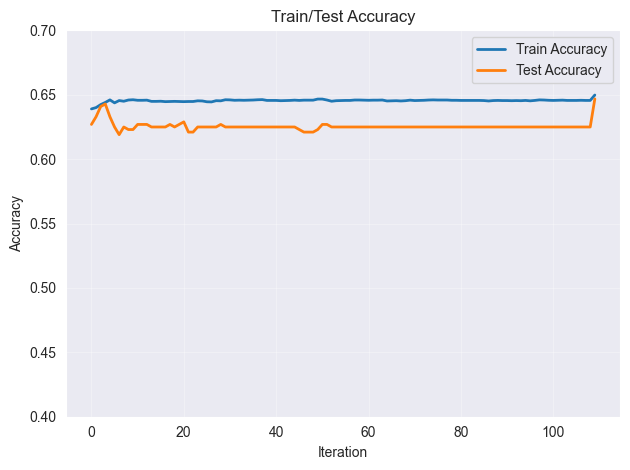

In [113]:
# --- Accuracy plot ---
plt.plot(iters, train_acc, label="Train Accuracy", color="#1f77b4", lw=2)
plt.plot(iters, test_acc,  label="Test Accuracy",  color="#ff7f0e", lw=2)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.ylim(0.4, 0.7)
plt.title("Train/Test Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

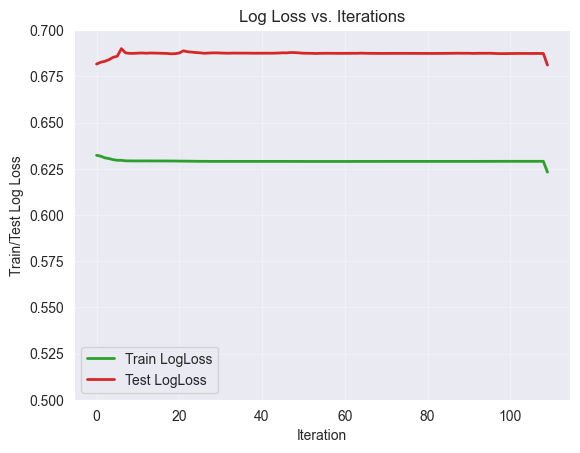

In [114]:
# Log-loss
plt.plot(iters, train_ll, label="Train LogLoss", color="#2ca02c", lw=2)
plt.plot(iters, test_ll,  label="Test LogLoss",  color="#d62728", lw=2)
ymin = np.nanmin([train_ll.min(), test_ll.min()])
ymax = np.nanmax([train_ll.max(), test_ll.max()])
plt.ylim(0.5, 0.7)
plt.xlabel("Iteration"); plt.ylabel("Train/Test Log Loss")
plt.title("Log Loss vs. Iterations"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [15]:
def calibration_curve_with_ci(y_true, p_pred, n_bins=10, strategy="uniform", title="Calibration Curve (Reliability Diagram)"):
    """
    Plots calibration curve with 95% binomial CIs for each bin.
    y_true: array-like of shape (n_samples,), values in {0,1}
    p_pred: array-like of predicted probabilities in [0,1]
    n_bins: number of bins
    strategy: "uniform" (equal-width in probability) or "quantile" (equal-count)
    """
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.clip(np.asarray(p_pred), 1e-12, 1-1e-12)

    df = pd.DataFrame({"y": y_true, "p": p_pred})

    if strategy == "quantile":
        # Bin by quantiles of predicted probability (equal count)
        # Ensure unique bin edges
        quantiles = np.linspace(0, 1, n_bins + 1)
        edges = np.unique(np.quantile(df["p"], quantiles))
        # If many ties shrink number of bins
        if len(edges) - 1 < n_bins:
            n_bins = len(edges) - 1
        df["bin"] = pd.cut(df["p"], bins=edges, include_lowest=True, duplicates="drop")
    elif strategy == "uniform":
        edges = np.linspace(0.0, 1.0, n_bins + 1)
        df["bin"] = pd.cut(df["p"], bins=edges, include_lowest=True)
    else:
        raise ValueError("strategy must be 'uniform' or 'quantile'")

    grp = df.groupby("bin", observed=False)
    n = grp.size().values
    if len(n) == 0:
        raise ValueError("No bins formed. Check inputs.")

    p_mean = grp["p"].mean().values
    y_mean = grp["y"].mean().values  # observed frequency
    # 95% binomial proportion CI using Wilson or Beta posterior (Jeffreys)
    # Here: Jeffreys interval via Beta(0.5,0.5) posterior for robustness in small bins.
    k = (grp["y"].sum()).values
    lower = beta_dist.ppf(0.025, k + 0.5, n - k + 0.5)
    upper = beta_dist.ppf(0.975, k + 0.5, n - k + 0.5)

    # Plot
    fig, ax = plt.subplots(figsize=(6.5, 6.0))
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Perfect calibration")
    ax.errorbar(p_mean, y_mean, yerr=[y_mean - lower, upper - y_mean],
                fmt="o", color="#1f77b4", ecolor="#1f77b4", elinewidth=1, capsize=3, label="Bins")
    # Bin sizes as marker size
    ms = 20 * (n / n.max())
    ax.scatter(p_mean, y_mean, s=ms, color="#1f77b4")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title(title + f"\n(n={len(y_true)}, bins={n_bins}, strategy={strategy})")
    ax.grid(alpha=0.2)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

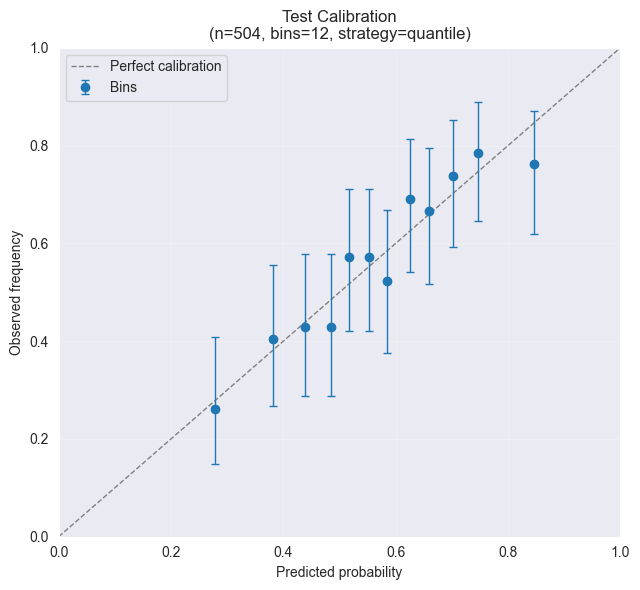

In [115]:
y_true_test = test['home_win'].astype(int).values
p_pred_test = model.predict_proba(test)
calibration_curve_with_ci(y_true_test, p_pred_test, n_bins=12, strategy="quantile", title="Test Calibration")

In [17]:
def normal_probability_plot_with_band(y_true, p_pred, n_sim=500, title="Normal Probability Plot of Standardized Residuals"):
    """
    Creates a Q–Q plot for standardized probability residuals r = (y - p) / sqrt(p(1-p)),
    with a 95% simulation band that accounts for heteroskedastic Bernoulli noise.
    The band is generated by parametric bootstrap under the fitted probabilities.
    """
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.clip(np.asarray(p_pred), 1e-12, 1-1e-12)

    # Standardized residuals (Pearson residuals for Bernoulli)
    r = (y_true - p_pred) / np.sqrt(p_pred * (1 - p_pred))

    # Sort residuals and their theoretical normal quantiles
    r_sorted = np.sort(r)
    n = len(r_sorted)
    probs = (np.arange(1, n + 1) - 0.5) / n
    z_theory = norm.ppf(probs)

    # Simulation band: simulate y* ~ Bernoulli(p_pred), compute residuals, take order stats
    rng = np.random.default_rng(12345)
    sim_order_stats = np.empty((n_sim, n), dtype=float)
    for s in range(n_sim):
        y_sim = rng.binomial(1, p_pred)
        r_sim = (y_sim - p_pred) / np.sqrt(p_pred * (1 - p_pred))
        sim_order_stats[s, :] = np.sort(r_sim)

    lower = np.quantile(sim_order_stats, 0.025, axis=0)
    upper = np.quantile(sim_order_stats, 0.975, axis=0)

    # Plot
    fig, ax = plt.subplots(figsize=(6.8, 6.0))
    ax.fill_between(z_theory, lower, upper, color="#d3e5ff", alpha=0.8, label="95% simulation band")
    ax.plot(z_theory, r_sorted, "o", ms=3, color="#1f77b4", label="Empirical residuals")
    ax.plot([z_theory.min(), z_theory.max()], [z_theory.min(), z_theory.max()],
            "--", color="gray", lw=1, label="y=x")

    ax.set_xlabel("Theoretical quantiles N(0,1)")
    ax.set_ylabel("Ordered residuals")
    ax.set_title(title + f"\n(n={n})")
    ax.grid(alpha=0.2)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

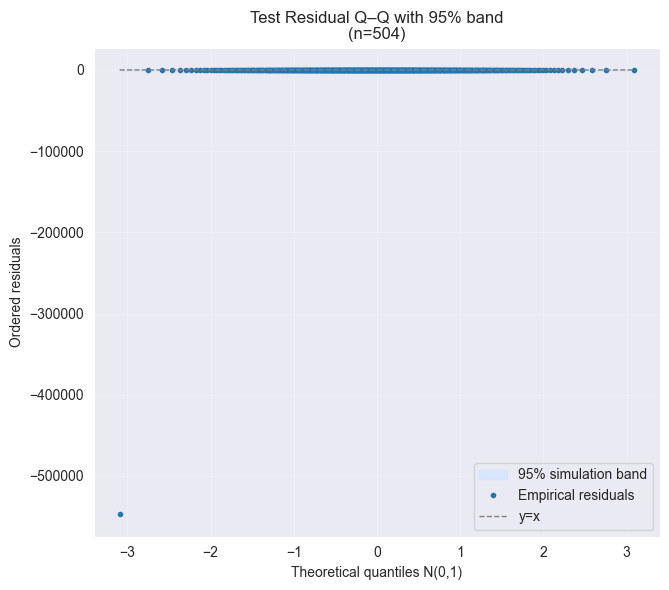

In [116]:
normal_probability_plot_with_band(y_true_test, p_pred_test, n_sim=800, title="Test Residual Q–Q with 95% band")

### 1.7 Optimization

### Method 1: Grid Search (Abandoned)

In [59]:
class BTWrapper(BaseEstimator, ClassifierMixin):
    """
    Minimal sklearn-compatible wrapper that uses BTWithCovariates *externally*.
    It does not modify your model; it just trains/evaluates it.
    """

    def __init__(self,
                 lambda_s=1e-3,
                 lambda_b=1e-3,
                 lambda_g=1e-3,
                 max_iter=800,
                 verbose=None):
        self.lambda_s = lambda_s
        self.lambda_b = lambda_b
        self.lambda_g = lambda_g
        self.max_iter = max_iter
        self.verbose = verbose


    def fit(self, X, y):
        # X must include all required columns (home_abbr, away_abbr, feature/context_cols)
        df_train = X.copy()
        df_train["home_win"] = y.astype(float)

        # Use closures for global game data and parameters already defined in your notebook
        global teams, team_to_idx, s_init, beta_init, feature_cols, mu, sd
        global context_cols, gamma_init, mu_context, sd_context

        self.model_ = BTWithCovariates(
            teams=teams,
            team_to_idx=team_to_idx,
            s=s_init.copy(),
            beta=beta_init.copy(),
            feature_cols=feature_cols,
            mu=mu, sd=sd,
            context_cols=context_cols,
            gamma=gamma_init.copy(),
            mu_context=mu_context, sd_context=sd_context,
            lambda_s=self.lambda_s,
            lambda_b=self.lambda_b,
            lambda_g=self.lambda_g,
            threshold=0.5,
        )

        self.model_.fit(
            df=df,
            split_col=None,
            max_iter=self.max_iter,
            verbose=self.verbose,
        )
        return self

    def predict(self, X):
        return self.model_.predict_class(X)

    def score(self, X, y):
        # Accuracy (used by GridSearchCV via scoring="accuracy")
        Xc = X.copy()
        Xc["home_win"] = y.astype(float)
        acc, _ = self.model_.evaluate(Xc)
        return acc


In [60]:
param_grid = {
    "lambda_s": np.logspace(-4, 4, 10),
    "lambda_b": np.logspace(-4, 1, 5),
    "lambda_g": np.logspace(-6, 1, 4),
}

X_train = df[df["split"] == "train"].drop(columns=["home_win", "split"])
y_train = df[df["split"] == "train"]["home_win"].astype(int)

X_test  = test.drop(columns=["home_win", "split"])
y_test  = test["home_win"].astype(int)

In [61]:
search = GridSearchCV(
    BTWrapper(),
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=2,
    refit=True,
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV accuracy:", search.best_score_)
best_model = search.best_estimator_
test_acc = best_model.score(X_test, y_test)
print("Test accuracy:", test_acc)

Fitting 3 folds for each of 200 candidates, totalling 600 fits
Estimated global home‑court multiplier θ̄ = 1.3460
Best params: {'lambda_b': np.float64(10.0), 'lambda_g': np.float64(0.04641588833612782), 'lambda_s': np.float64(0.3593813663804626)}
Best CV accuracy: 0.6530699697899541
Test accuracy: 0.6434886499402629


C:\Users\hosiu\AppData\Local\Temp\ipykernel_30152\3683839019.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


In [63]:
df = pd.DataFrame(search.cv_results_)
print(df.columns.tolist())

['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_lambda_b', 'param_lambda_g', 'param_lambda_s', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score']


In [67]:
top_df = df.nlargest(int(len(df) * 0.2), 'mean_test_score')

fig = go.Figure(data=go.Parcoords(
    line=dict(
        color=top_df['mean_test_score'],
        colorscale='Viridis',
        cmin=df['mean_test_score'].min(),
        cmax=df['mean_test_score'].max(),
        showscale=True,
        colorbar=dict(title='CV Accuracy')
    ),
    dimensions=[
        dict(label='log₁₀(λₛ)', values=top_df['log_lambda_s']),
        dict(label='log₁₀(λᵦ)', values=top_df['log_lambda_b']),
        dict(label='log₁₀(λg)', values=top_df['log_lambda_g']),
        dict(label='Mean CV Accuracy', values=top_df['mean_test_score'])
    ]
))

fig.update_layout(
    title='Top 20% Best Configs — Parallel Coordinates (λ Parameters)',
    font=dict(size=12),
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig.show()

In [30]:
model = BTWithCovariates(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init,
    beta=beta_init,
    feature_cols=feature_cols,
    mu=mu,
    sd=sd,
    lambda_s=21.54434690031882,
    lambda_b=10.0,
    lambda_g=1e-06,
    threshold=0.5,
    context_cols=context_cols,
    gamma=gamma_init,
    mu_context=mu_context, sd_context=sd_context
)

result = model.fit(
    df=df,
    split_col="split",
    split_value="train",
    test_frame=test,
    max_iter=800,
    verbose=1,
)

# Final metrics (you can also recompute)
tr_acc,tr_ll = model.evaluate(train)
t_acc, t_ll = model.evaluate(test)
print(f"Train Metric -> acc={tr_acc:.6f} ll={tr_ll:.6f}")
print(f"Test Metric -> acc={t_acc:.6f} ll={t_ll:.6f}")
test["p_home"] = model.predict_proba(test)
test["pred_win"] = model.predict_class(test)

Running 5 MM iterations for initial team strength update...
[0000] Train acc=0.6393 ll=0.6323 | Test acc=0.6191 ll=0.6647
[0001] Train acc=0.6402 ll=0.6318 | Test acc=0.6225 ll=0.6644
[0002] Train acc=0.6425 ll=0.6309 | Test acc=0.6220 ll=0.6639
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6215 ll=0.6639
[0004] Train acc=0.6464 ll=0.6299 | Test acc=0.6220 ll=0.6645
[0005] Train acc=0.6440 ll=0.6296 | Test acc=0.6167 ll=0.6663
[0006] Train acc=0.6451 ll=0.6295 | Test acc=0.6189 ll=0.6663
[0007] Train acc=0.6448 ll=0.6294 | Test acc=0.6182 ll=0.6666
[0008] Train acc=0.6459 ll=0.6293 | Test acc=0.6174 ll=0.6668
[0009] Train acc=0.6453 ll=0.6293 | Test acc=0.6172 ll=0.6669
[0010] Train acc=0.6453 ll=0.6293 | Test acc=0.6174 ll=0.6669
[0011] Train acc=0.6453 ll=0.6293 | Test acc=0.6165 ll=0.6669
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6179 ll=0.6669
[0013] Train acc=0.6458 ll=0.6292 | Test acc=0.6179 ll=0.6669
Estimated global home‑court multiplier θ̄ = 1.3855
Final: Train acc=0.64

C:\Users\hosiu\AppData\Local\Temp\ipykernel_30152\3683839019.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


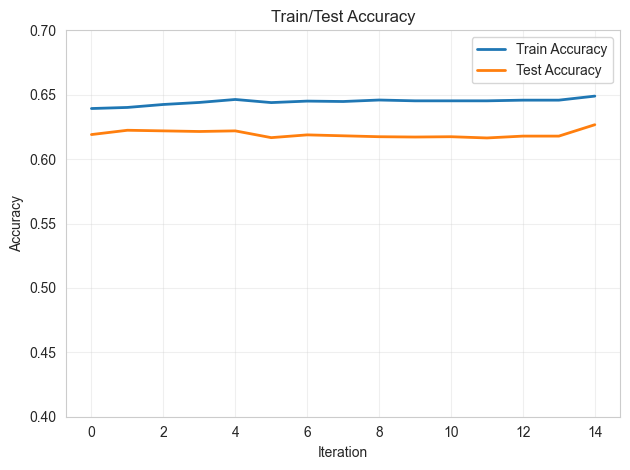

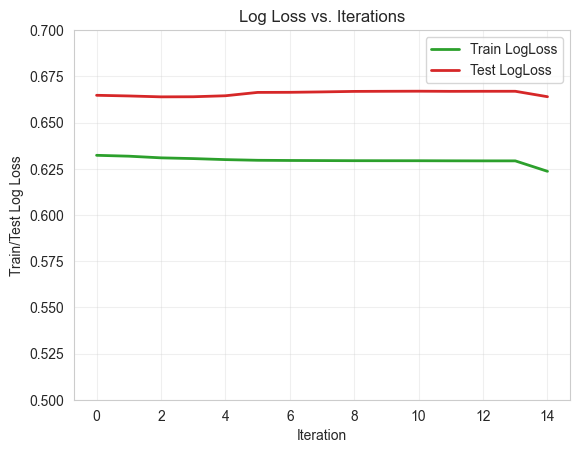

In [69]:
# --- Convert to numpy arrays for plotting ---
hist_grid = result["history"]

# convert arrays safely
iters     = np.array(hist_grid["iter"], dtype=float)
train_acc = np.array(hist_grid["train_acc"], dtype=float)
test_acc  = np.array(hist_grid["test_acc"], dtype=float)
train_ll  = np.array(hist_grid["train_logloss"], dtype=float)
test_ll   = np.array(hist_grid["test_logloss"], dtype=float)

# --- 1Train vs Test Accuracy ---
plt.plot(iters, train_acc, label="Train Accuracy", color="#1f77b4", lw=2)
plt.plot(iters, test_acc,  label="Test Accuracy",  color="#ff7f0e", lw=2)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.ylim(0.4, 0.7)
plt.title("Train/Test Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Train vs Test Log-Loss ---
plt.plot(iters, train_ll, label="Train LogLoss", color="#2ca02c", lw=2)
plt.plot(iters, test_ll,  label="Test LogLoss",  color="#d62728", lw=2)
ymin = np.nanmin([train_ll.min(), test_ll.min()])
ymax = np.nanmax([train_ll.max(), test_ll.max()])
plt.ylim(0.5, 0.7)
plt.xlabel("Iteration"); plt.ylabel("Train/Test Log Loss")
plt.title("Log Loss vs. Iterations"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Method 2: Bayesian Search

In [21]:
space  = [
    Real(1e-4, 1e1,   "log-uniform", name="lambda_s"),
    Real(1e-4, 1e1,   "log-uniform", name="lambda_b"),
    Real(1e-6, 1e-1, "log-uniform", name="lambda_g"),
]

all_results = []

@use_named_args(space)
def objective(lambda_s, lambda_b,lambda_g):
    print(f"Trying λs={lambda_s:.4e}, λb={lambda_b:.4e}, λg={lambda_g:.4e}")


    model = BTWithCovariates(
        teams=teams,
        team_to_idx=team_to_idx,
        s=s_init,
        beta=beta_init,
        feature_cols=feature_cols,
        mu=mu,
        sd=sd,
        lambda_s=lambda_s,
        lambda_b=lambda_b,
        lambda_g=lambda_g,
        threshold=0.5,
        context_cols=context_cols,
        gamma=gamma_init,
        mu_context=mu_context, sd_context=sd_context
    )

    result = model.fit(
        df=df,
        split_col="split",
        split_value="train",
        test_frame=test,
        max_iter=800,
        verbose=1,
    )

    acc, logloss = model.evaluate(test)

    print(f"Accuracy: {acc:.6f}")
    print(f"Logloss: {logloss:.6f}")

    # record each step for analysis later
    all_results.append({
        "lambda_s": lambda_s,
        "lambda_b": lambda_b,
        "lambda_g": lambda_g,
        "accuracy": acc,
        "logloss": logloss,
    })

    return -acc

In [22]:
result = gp_minimize(
    func=objective,
    dimensions=space,
    n_calls=50,           # number of trials (start with 25–50)
    n_initial_points=10,  # random explorations before GP fit
    random_state=42,
    acq_func="EI"         # Expected Improvement
)

Trying λs=9.6098e-01, λb=8.2637e-04, λg=7.9151e-03
Running 5 MM iterations for initial team strength update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_30152\3683839019.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6191 ll=0.6647
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6225 ll=0.6644
[0002] Train acc=0.6425 ll=0.6309 | Test acc=0.6217 ll=0.6639
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6217 ll=0.6639
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6220 ll=0.6645
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6160 ll=0.6663
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6162 ll=0.6672
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6174 ll=0.6675
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6172 ll=0.6676
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6177 ll=0.6679
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6170 ll=0.6681
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6165 ll=0.6683
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6162 ll=0.6684
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6162 ll=0.6685
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6165 ll=0.6685
[0015] Train acc=0.6446 ll=0.6292 | Test acc=0.6174 ll=0.6685
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_30152\3683839019.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6191 ll=0.6647
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6225 ll=0.6644
[0002] Train acc=0.6424 ll=0.6309 | Test acc=0.6217 ll=0.6639
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6217 ll=0.6639
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6220 ll=0.6645
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6160 ll=0.6663
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6162 ll=0.6672
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6174 ll=0.6675
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6172 ll=0.6676
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6177 ll=0.6679
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6170 ll=0.6681
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6165 ll=0.6683
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6170 ll=0.6684
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6162 ll=0.6685
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6165 ll=0.6685
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6167 ll=0.6685
[0016] T

...

[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6191 ll=0.6647
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6225 ll=0.6644
[0002] Train acc=0.6425 ll=0.6309 | Test acc=0.6217 ll=0.6639
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6217 ll=0.6639
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6220 ll=0.6645
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6160 ll=0.6663
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6162 ll=0.6672
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6174 ll=0.6675
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6172 ll=0.6676
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6177 ll=0.6679
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6170 ll=0.6681
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6165 ll=0.6683
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6170 ll=0.6684
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6162 ll=0.6685
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6165 ll=0.6685
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6167 ll=0.6685
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_30152\3683839019.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6191 ll=0.6647
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6225 ll=0.6644
[0002] Train acc=0.6425 ll=0.6309 | Test acc=0.6217 ll=0.6639
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6217 ll=0.6639
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6220 ll=0.6645
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6160 ll=0.6663
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6162 ll=0.6672
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6174 ll=0.6675
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6172 ll=0.6676
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6177 ll=0.6679
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6170 ll=0.6681
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6165 ll=0.6683
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6170 ll=0.6684
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6162 ll=0.6685
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6165 ll=0.6685
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6167 ll=0.6685
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_30152\3683839019.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6191 ll=0.6647
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6225 ll=0.6644
[0002] Train acc=0.6424 ll=0.6309 | Test acc=0.6217 ll=0.6639
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6217 ll=0.6639
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6220 ll=0.6645
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6160 ll=0.6663
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6162 ll=0.6672
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6174 ll=0.6675
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6172 ll=0.6676
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6177 ll=0.6679
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6170 ll=0.6681
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6165 ll=0.6683
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6170 ll=0.6684
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6162 ll=0.6685
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6165 ll=0.6685
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6167 ll=0.6685
[0016] T


Optimization completed
Best parameters: λs=1.2229e-01, λb=1.1436e-01, λg=1.0848e-06
Best accuracy: 0.626045
Best logloss: 0.669789


<Axes: >

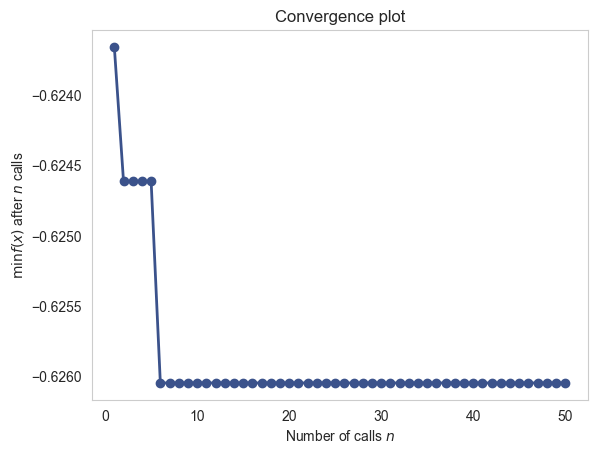

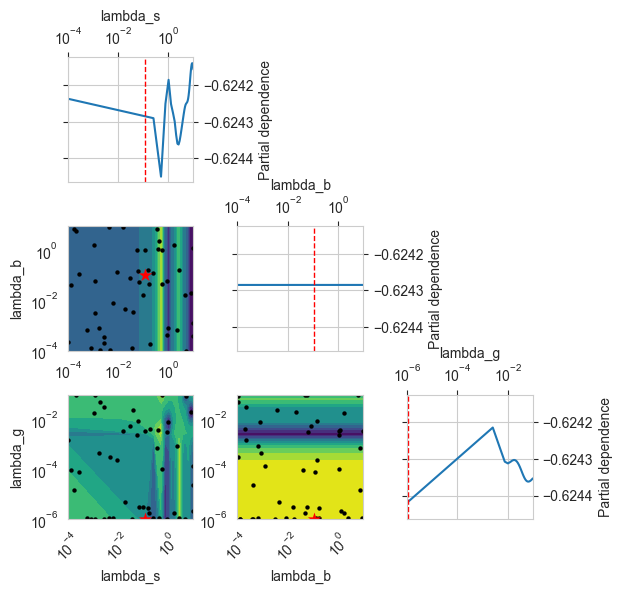

In [25]:
# best parameters found
best_lambda_s, best_lambda_b, best_lambda_g = result.x
# convert back to positive accuracy
best_acc = -result.fun
# find the matching logloss from our stored results
best_entry = min(all_results, key=lambda r: abs(r["accuracy"] - best_acc))
best_logloss = best_entry["logloss"]

print("\nOptimization completed")
print(f"Best parameters: λs={best_lambda_s:.4e}, λb={best_lambda_b:.4e}, λg={best_lambda_g:.4e}")
print(f"Best accuracy: {best_acc:.6f}")
print(f"Best logloss: {best_logloss:.6f}")

plot_convergence(result)
plot_objective(result)

In [26]:
model = BTWithCovariates(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init,
    beta=beta_init,
    feature_cols=feature_cols,
    mu=mu,
    sd=sd,
    lambda_s=1.2229e-01,
    lambda_b=1.1436e-01,
    lambda_g=1.0848e-06,
    threshold=0.5,
    context_cols=context_cols,
    gamma=gamma_init,
    mu_context=mu_context, sd_context=sd_context
)


result = model.fit(
    df,
    split_col="split",
    split_value="train",
    max_iter=10000,
    verbose=1,
    test_frame=test,
)

# Final metrics (you can also recompute)
tr_acc,tr_ll = model.evaluate(train)
t_acc, t_ll = model.evaluate(test)
print(f"Train Metric -> acc={tr_acc:.6f} ll={tr_ll:.6f}")
print(f"Test Metric -> acc={t_acc:.6f} ll={t_ll:.6f}")

Running 5 MM iterations for initial team strength update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_30152\3683839019.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6191 ll=0.6647
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6225 ll=0.6644
[0002] Train acc=0.6425 ll=0.6309 | Test acc=0.6217 ll=0.6639
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6217 ll=0.6639
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6220 ll=0.6645
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6160 ll=0.6663
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6162 ll=0.6672
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6174 ll=0.6675
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6172 ll=0.6676
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6177 ll=0.6679
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6170 ll=0.6681
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6165 ll=0.6683
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6170 ll=0.6684
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6162 ll=0.6685
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6165 ll=0.6685
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6167 ll=0.6685
[0016] T

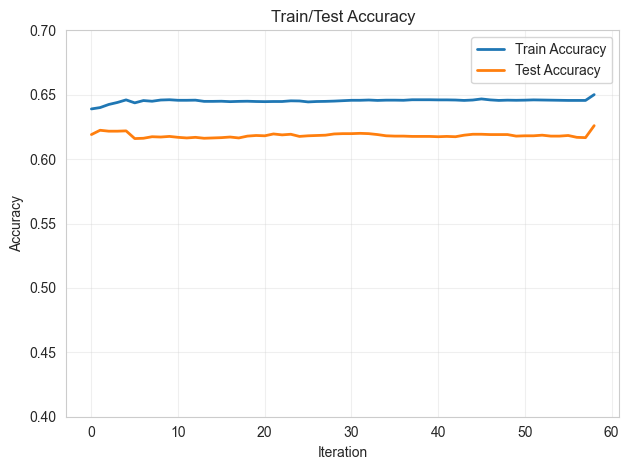

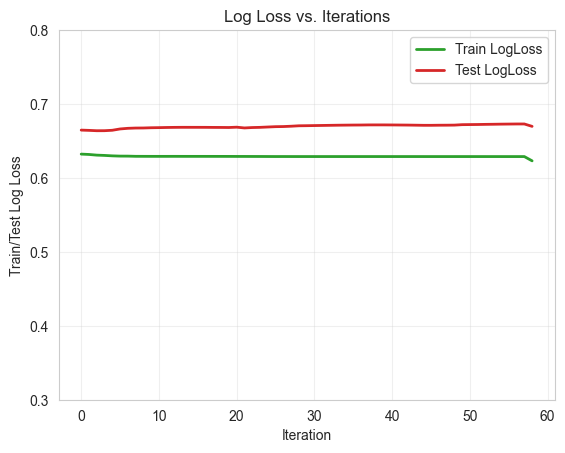

In [28]:
# --- Convert to numpy arrays for plotting ---
hist_baye = result["history"]

# convert arrays safely
iters     = np.array(hist_baye["iter"], dtype=float)
train_acc = np.array(hist_baye["train_acc"], dtype=float)
test_acc  = np.array(hist_baye["test_acc"], dtype=float)
train_ll  = np.array(hist_baye["train_logloss"], dtype=float)
test_ll   = np.array(hist_baye["test_logloss"], dtype=float)

# --- 1Train vs Test Accuracy ---
plt.plot(iters, train_acc, label="Train Accuracy", color="#1f77b4", lw=2)
plt.plot(iters, test_acc,  label="Test Accuracy",  color="#ff7f0e", lw=2)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.ylim(0.4, 0.7)
plt.title("Train/Test Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Train vs Test Log-Loss ---
plt.plot(iters, train_ll, label="Train LogLoss", color="#2ca02c", lw=2)
plt.plot(iters, test_ll,  label="Test LogLoss",  color="#d62728", lw=2)
ymin = np.nanmin([train_ll.min(), test_ll.min()])
ymax = np.nanmax([train_ll.max(), test_ll.max()])
plt.ylim(0.3, 0.8)
plt.xlabel("Iteration"); plt.ylabel("Train/Test Log Loss")
plt.title("Log Loss vs. Iterations"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Stratified KFold

Select Best K

In [133]:
K = 30 # number of folds
max_iter = 1200     # training iterations per fold

# storage lists
fold_results = []
df_cv = df.drop(columns=["split"])
# The target variable for stratification
y = df_cv["home_win"].values
# Create StratifiedKFold object
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)


for fold, (train_idx, test_idx) in enumerate(skf.split(df_cv, y), 1):
    print(f"\nFold {fold}/{K}")

    train = df.iloc[train_idx]
    test  = df.iloc[test_idx]

    model = BTWithCovariates(
        teams=teams,
        team_to_idx=team_to_idx,
        s=s_init,
        beta=beta_init,
        feature_cols=feature_cols,
        mu=mu,
        sd=sd,
        lambda_s=1.2229e-01,
        lambda_b=1.1436e-01,
        lambda_g=1.0848e-06,
        threshold=0.5,
        context_cols=context_cols,
        gamma=gamma_init,
        mu_context=mu_context, sd_context=sd_context
    )


    result = model.fit(
        df,
        split_col="split",
        split_value="train",
        max_iter=10000,
        verbose=1,
        test_frame=test,
    )

    # Evaluate model on both folds
    train_acc, train_ll = model.evaluate(train)
    test_acc, test_ll   = model.evaluate(test)

    print(f"Fold {fold:>2}: Train acc={train_acc:.3f}, logloss={train_ll:.4f} | "
          f"Test acc={test_acc:.3f}, logloss={test_ll:.4f}")

    fold_results.append({
        "fold": fold,
        "train_acc": train_acc,
        "train_ll": train_ll,
        "test_acc": test_acc,
        "test_ll": test_ll,
    })

# Aggregate results
results_df = pd.DataFrame(fold_results)
print("\nCross‑Validation Summary")
print(results_df)

print("\nMean metrics across folds:")
print(results_df.mean(numeric_only=True).to_frame().T.round(4))


Fold 1/30
Running 5 MM iterations for initial team strength update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_26692\39330441.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6020 ll=0.6616
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6059 ll=0.6605
[0002] Train acc=0.6425 ll=0.6309 | Test acc=0.6020 ll=0.6586
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6020 ll=0.6581
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6059 ll=0.6570
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6119 ll=0.6578
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6139 ll=0.6582
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6158 ll=0.6590
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6119 ll=0.6593
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6119 ll=0.6598
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6099 ll=0.6595
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6099 ll=0.6596
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6059 ll=0.6598
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6040 ll=0.6597
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6040 ll=0.6597
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6040 ll=0.6597
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26692\39330441.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6495 ll=0.6241
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6455 ll=0.6242
[0002] Train acc=0.6425 ll=0.6309 | Test acc=0.6396 ll=0.6255
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6455 ll=0.6257
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6416 ll=0.6274
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6337 ll=0.6283
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6356 ll=0.6273
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6317 ll=0.6276
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6297 ll=0.6275
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6297 ll=0.6276
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6337 ll=0.6278
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6337 ll=0.6280
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6317 ll=0.6277
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6297 ll=0.6280
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6317 ll=0.6280
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6317 ll=0.6280
[0016] T

...

[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6587 ll=0.6357
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6587 ll=0.6353
[0002] Train acc=0.6425 ll=0.6309 | Test acc=0.6667 ll=0.6345
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6706 ll=0.6344
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6726 ll=0.6342
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6567 ll=0.6350
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6567 ll=0.6339
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6508 ll=0.6347
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6528 ll=0.6348
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6587 ll=0.6349
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6587 ll=0.6349
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6587 ll=0.6350
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6587 ll=0.6352
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6587 ll=0.6352
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6587 ll=0.6353
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6587 ll=0.6353
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26692\39330441.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6389 ll=0.6411
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6448 ll=0.6402
[0002] Train acc=0.6425 ll=0.6309 | Test acc=0.6508 ll=0.6395
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6607 ll=0.6384
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6567 ll=0.6380
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6429 ll=0.6380
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6409 ll=0.6398
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6429 ll=0.6385
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6429 ll=0.6383
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6389 ll=0.6380
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6369 ll=0.6381
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6349 ll=0.6382
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6369 ll=0.6384
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6329 ll=0.6384
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6329 ll=0.6384
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6329 ll=0.6384
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26692\39330441.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6270 ll=0.6816
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6329 ll=0.6826
[0002] Train acc=0.6425 ll=0.6309 | Test acc=0.6409 ll=0.6831
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6429 ll=0.6840
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6329 ll=0.6853
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6250 ll=0.6859
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6190 ll=0.6900
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6250 ll=0.6877
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6230 ll=0.6874
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6230 ll=0.6874
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6270 ll=0.6875
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6270 ll=0.6876
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6270 ll=0.6875
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6250 ll=0.6876
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6250 ll=0.6876
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6250 ll=0.6875
[0016] T

Found K=13 is the best among 30 folds, Lock K=13

In [135]:
K = 13     #chosen from empirical test
max_iter = 1200

fold_results = []
df_cv = df[df["split"].isin(["train", "test"])]
y = df_cv["home_win"].values

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)


for fold, (train_idx, test_idx) in enumerate(skf.split(df_cv, y), 1):
    print(f"\nFold {fold}/{K}")

    train_df = df_cv.iloc[train_idx].copy()
    test_df  = df_cv.iloc[test_idx].copy()

    model = BTWithCovariates(
        teams=teams,
        team_to_idx=team_to_idx,
        s=s_init,
        beta=beta_init,
        feature_cols=feature_cols,
        mu=mu,
        sd=sd,
        lambda_s=1.2229e-01,
        lambda_b=1.1436e-01,
        lambda_g=1.0848e-06,
        threshold=0.5,
        context_cols=context_cols,
        gamma=gamma_init,
        mu_context=mu_context, sd_context=sd_context
    )


    result = model.fit(
        df_cv,
        split_col="split",
        split_value="train",
        max_iter=10000,
        verbose=1,
        test_frame=test,
    )

    train_acc, train_ll = model.evaluate(train_df)
    test_acc, test_ll   = model.evaluate(test_df)

    fold_results.append({
        "fold": fold,
        "train_acc": train_acc,
        "train_ll": train_ll,
        "test_acc": test_acc,
        "test_ll": test_ll,
    })

    print(
        f"Fold {fold:>2}: Train acc={train_acc:.4f}, logloss={train_ll:.4f} | "
        f"Test acc={test_acc:.4f}, logloss={test_ll:.4f}"
    )

# ---- Summaries ----
results_df = pd.DataFrame(fold_results)
print("\nCross‑Validation Summary (K=12)")
print(results_df)
print("\nMean metrics across folds:")
print(results_df.mean(numeric_only=True).to_frame().T.round(4))


Fold 1/13
Running 5 MM iterations for initial team strength update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_26692\39330441.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6270 ll=0.6816
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6329 ll=0.6826
[0002] Train acc=0.6425 ll=0.6309 | Test acc=0.6409 ll=0.6831
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6429 ll=0.6840
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6329 ll=0.6853
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6250 ll=0.6859
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6190 ll=0.6900
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6250 ll=0.6877
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6230 ll=0.6874
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6230 ll=0.6874
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6270 ll=0.6875
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6270 ll=0.6876
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6270 ll=0.6875
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6250 ll=0.6876
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6250 ll=0.6876
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6250 ll=0.6875
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26692\39330441.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6270 ll=0.6816
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6329 ll=0.6826
[0002] Train acc=0.6425 ll=0.6309 | Test acc=0.6409 ll=0.6831
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6429 ll=0.6840
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6329 ll=0.6853
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6250 ll=0.6859
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6190 ll=0.6900
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6250 ll=0.6877
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6230 ll=0.6874
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6230 ll=0.6874
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6270 ll=0.6875
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6270 ll=0.6876
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6270 ll=0.6875
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6250 ll=0.6876
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6250 ll=0.6876
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6250 ll=0.6875
[0016] T

...

[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6270 ll=0.6816
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6329 ll=0.6826
[0002] Train acc=0.6425 ll=0.6309 | Test acc=0.6409 ll=0.6831
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6429 ll=0.6840
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6329 ll=0.6853
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6250 ll=0.6859
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6190 ll=0.6900
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6250 ll=0.6877
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6230 ll=0.6874
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6230 ll=0.6874
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6270 ll=0.6875
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6270 ll=0.6876
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6270 ll=0.6875
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6250 ll=0.6876
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6250 ll=0.6876
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6250 ll=0.6875
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26692\39330441.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6270 ll=0.6816
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6329 ll=0.6826
[0002] Train acc=0.6425 ll=0.6309 | Test acc=0.6409 ll=0.6831
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6429 ll=0.6840
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6329 ll=0.6853
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6250 ll=0.6859
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6190 ll=0.6900
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6250 ll=0.6877
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6230 ll=0.6874
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6230 ll=0.6874
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6270 ll=0.6875
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6270 ll=0.6876
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6270 ll=0.6875
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6250 ll=0.6876
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6250 ll=0.6876
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6250 ll=0.6875
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26692\39330441.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6390 ll=0.6323 | Test acc=0.6270 ll=0.6816
[0001] Train acc=0.6401 ll=0.6318 | Test acc=0.6329 ll=0.6826
[0002] Train acc=0.6425 ll=0.6309 | Test acc=0.6409 ll=0.6831
[0003] Train acc=0.6441 ll=0.6305 | Test acc=0.6429 ll=0.6840
[0004] Train acc=0.6460 ll=0.6299 | Test acc=0.6329 ll=0.6853
[0005] Train acc=0.6437 ll=0.6296 | Test acc=0.6250 ll=0.6859
[0006] Train acc=0.6455 ll=0.6295 | Test acc=0.6190 ll=0.6900
[0007] Train acc=0.6450 ll=0.6293 | Test acc=0.6250 ll=0.6877
[0008] Train acc=0.6459 ll=0.6292 | Test acc=0.6230 ll=0.6874
[0009] Train acc=0.6462 ll=0.6292 | Test acc=0.6230 ll=0.6874
[0010] Train acc=0.6457 ll=0.6292 | Test acc=0.6270 ll=0.6875
[0011] Train acc=0.6457 ll=0.6292 | Test acc=0.6270 ll=0.6876
[0012] Train acc=0.6458 ll=0.6292 | Test acc=0.6270 ll=0.6875
[0013] Train acc=0.6449 ll=0.6292 | Test acc=0.6250 ll=0.6876
[0014] Train acc=0.6449 ll=0.6292 | Test acc=0.6250 ll=0.6876
[0015] Train acc=0.6450 ll=0.6292 | Test acc=0.6250 ll=0.6875
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26692\4229385181.py:24: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hosiu\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


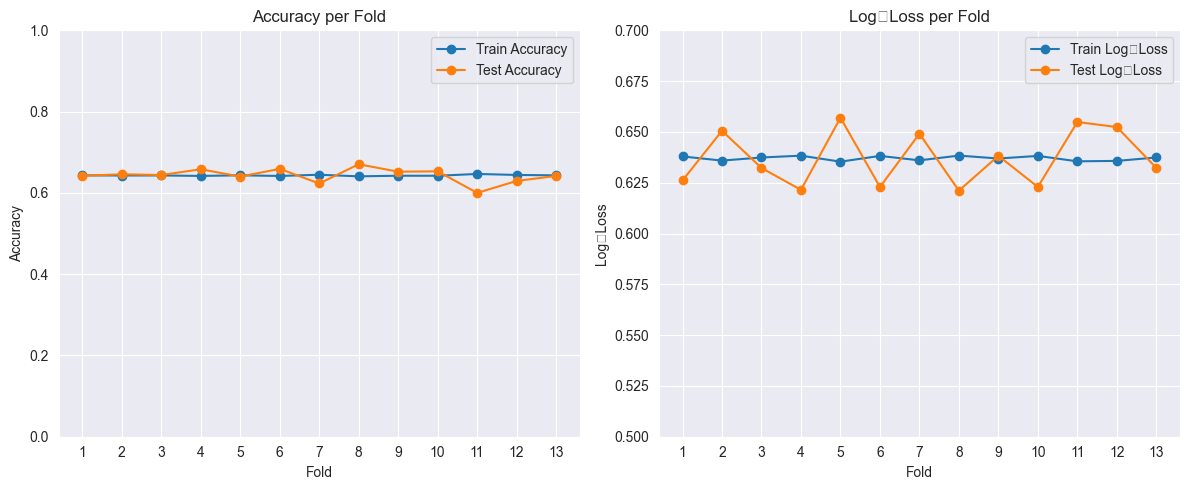


Cross‑validated accuracy (95% CI): 0.643 [0.633, 0.653]


In [136]:
# Figure setup
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ----- Plot 1: Accuracy -----
axes[0].plot(results_df["fold"], results_df["train_acc"], marker="o", label="Train Accuracy")
axes[0].plot(results_df["fold"], results_df["test_acc"], marker="o", label="Test Accuracy")
axes[0].set_title("Accuracy per Fold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Accuracy")
axes[1].set_ylim(0.5,0.7)
axes[0].set_xticks(results_df["fold"])
axes[0].legend()
axes[0].set_ylim(0, 1)  # accuracy ranges 0-1

# ----- Plot 2: Log‑Loss -----
axes[1].plot(results_df["fold"], results_df["train_ll"], marker="o", label="Train Log‑Loss")
axes[1].plot(results_df["fold"], results_df["test_ll"], marker="o", label="Test Log‑Loss")
axes[1].set_ylim(0.5,0.7)
axes[1].set_title("Log‑Loss per Fold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Log‑Loss")
axes[1].set_xticks(results_df["fold"])
axes[1].legend()

plt.tight_layout()
plt.show()

mean_acc = results_df["test_acc"].mean()
std_acc = results_df["test_acc"].std()
conf_low = mean_acc - 1.96 * std_acc / (K ** 0.5)
conf_high = mean_acc + 1.96 * std_acc / (K ** 0.5)

print(f"\nCross‑validated accuracy (95% CI): {mean_acc:.3f} "
      f"[{conf_low:.3f}, {conf_high:.3f}]")

### Finalized Model

In [137]:
final_df = pd.concat([train, test], axis=0).reset_index(drop=True)
final_df.drop(["split"], axis=1, inplace=True)
final_df.head()

,season,GAME_ID,home_abbr,away_abbr,home_win,home_b2b,away_b2b,home_rest_days,away_rest_days,rest_diff,diff_recent_margin,diff_recent_win_pct,diff_pts_pg_to_date,split_win_pct_delta,season_start_year
0,2014-15,41400406,CLE,GSW,0,0.0,0,1.0,1.0,0.0,-3.7,0.0,-5.162121,0.090909,2014
1,2014-15,41400405,GSW,CLE,1,0.0,0,2.0,2.0,0.0,1.9,-0.1,4.967933,0.349003,2014
2,2014-15,41400404,CLE,GSW,0,0.0,0,1.0,1.0,0.0,0.5,0.2,-4.620545,0.111111,2014
3,2014-15,41400403,CLE,GSW,1,0.0,0,1.0,1.0,0.0,-2.5,0.0,-4.757187,0.094340,2014
4,2014-15,41400402,GSW,CLE,0,0.0,0,2.0,2.0,0.0,0.4,0.0,4.839260,0.374769,2014


In [138]:
final_model = BTWithCovariates(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init,
    beta=beta_init,
    feature_cols=feature_cols,
    mu=mu,
    sd=sd,
    lambda_s=1.2229e-01,
    lambda_b=1.1436e-01,
    lambda_g=1.0848e-06,
    threshold=0.5,
    context_cols=context_cols,
    gamma=gamma_init,
    mu_context=mu_context,
    sd_context=sd_context,
)

# Fit using all combined training data
final_model.fit(
    df=final_df,
    max_iter=max_iter,
    verbose=1,
)

Running 5 MM iterations for initial team strength update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_26692\39330441.py:242: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6395 ll=0.6367 | Test acc=nan ll=nan
[0001] Train acc=0.6416 ll=0.6362 | Test acc=nan ll=nan
[0002] Train acc=0.6424 ll=0.6353 | Test acc=nan ll=nan
[0003] Train acc=0.6406 ll=0.6349 | Test acc=nan ll=nan
[0004] Train acc=0.6417 ll=0.6345 | Test acc=nan ll=nan
[0005] Train acc=0.6418 ll=0.6344 | Test acc=nan ll=nan
[0006] Train acc=0.6419 ll=0.6342 | Test acc=nan ll=nan
[0007] Train acc=0.6426 ll=0.6341 | Test acc=nan ll=nan
[0008] Train acc=0.6430 ll=0.6341 | Test acc=nan ll=nan
[0009] Train acc=0.6430 ll=0.6341 | Test acc=nan ll=nan
[0010] Train acc=0.6429 ll=0.6341 | Test acc=nan ll=nan
[0011] Train acc=0.6428 ll=0.6341 | Test acc=nan ll=nan
[0012] Train acc=0.6422 ll=0.6341 | Test acc=nan ll=nan
[0013] Train acc=0.6424 ll=0.6341 | Test acc=nan ll=nan
[0014] Train acc=0.6427 ll=0.6341 | Test acc=nan ll=nan
[0015] Train acc=0.6428 ll=0.6341 | Test acc=nan ll=nan
[0016] Train acc=0.6424 ll=0.6341 | Test acc=nan ll=nan
[0017] Train acc=0.6424 ll=0.6341 | Test acc=nan

{'opt_result':   message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
   success: True
    status: 0
       fun: 10154.300963826401
         x: [ 9.000e+00  8.790e+00 ...  2.800e-01  3.033e-01]
       nit: 105
       jac: [ 8.084e-04  7.158e-02 ...  1.831e-01  5.783e-02]
      nfev: 140
      njev: 140
  hess_inv: <75x75 LbfgsInvHessProduct with dtype=float64>,
 'history': {'iter': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
  

### Save Model

In [139]:
save_model(
    final_model,
    path_npz="models/btwithcovariates_fold13.npz",
    path_json="models/btwithcovariates_fold13.json",
    extra_meta={"K": K, "max_iter": max_iter},
)

Model parameters saved to models/btwithcovariates_fold13.json
Model saved successfully to models/btwithcovariates_fold13.npz


### 1.B Validation

Model loaded successfully from models/btwithcovariates_fold13.npz
Teams: 65 | Features: 4


C:\Users\hosiu\AppData\Local\Temp\ipykernel_30152\3452764545.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\hosiu\AppData\Local\Temp\ipykernel_30152\3452764545.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\hosiu\AppData\Local\Temp\ipykernel_30152\3452764545.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

,home_abbr,away_abbr,HCA_total,theta_game,pred_prob_home_win,pred_label,home_win
13708,OKC,IND,0.067121,1.069425,0.672403,1,1
13709,IND,OKC,0.067121,1.069425,0.331480,0,1
13710,OKC,IND,0.067121,1.069425,0.703849,1,1
13711,IND,OKC,0.062168,1.064141,0.344901,0,0
13712,IND,OKC,0.067121,1.069425,0.340125,0,1
...,...,...,...,...,...,...,...
15097,SAS,IND,0.036067,1.036726,0.433651,0,1
15098,IND,SAS,0.062168,1.064141,0.556969,1,1
15099,MIL,ATL,0.108082,1.114139,0.622501,1,1
15100,OKC,HOU,0.108082,1.114139,0.646348,1,1


Evaluation Metrics on Validation Data
Accuracy : 0.6492
Log Loss : 0.6238
Precision: 0.6794
Recall   : 0.6909
F1 Score : 0.6851


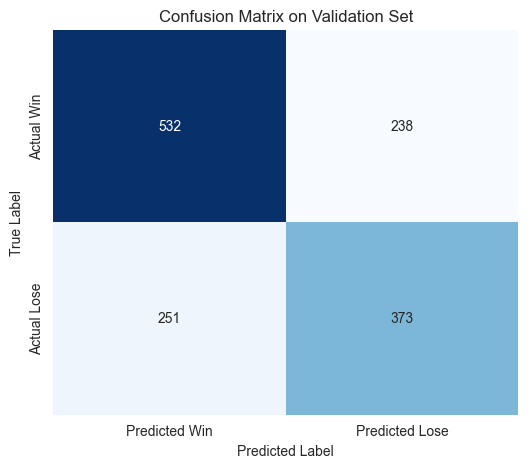

In [73]:
model = load_model("models/btwithcovariates_fold13.npz")
valid_df = df[df["split"] == "valid"]

# Standardize context columns
Z_valid = np.zeros((len(valid_df), len(model.context_cols)))
for j, col in enumerate(model.context_cols):
    Z_valid[:, j] = (valid_df[col] - model.mu_context[j]) / model.sd_context[j]
# Compute contextual home advantage for each game
valid_df["HCA_context"] = Z_valid @ model.gamma
valid_df["HCA_total"] = model.alpha_hca + Z_valid @ model.gamma
valid_df["theta_game"] = np.exp(valid_df["HCA_total"])

valid_df["pred_prob_home_win"] = model.predict_proba(valid_df)
# For classification label
valid_df["pred_label"] = (valid_df["pred_prob_home_win"] >= model.threshold).astype(int)
valid_df = valid_df[(valid_df["home_abbr"] != "NONE") & (valid_df["away_abbr"].notna())]
valid_df=valid_df[["home_abbr", "away_abbr", "HCA_total", "theta_game", "pred_prob_home_win", "pred_label","home_win"]]
display(valid_df)

valid_df.to_csv("./results/valid_result.csv", index=False)

# --- Extract prediction and true labels ---
y_true = valid_df["home_win"]
y_pred = valid_df["pred_label"]

# --- Compute evaluation metrics ---
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
logloss = log_loss(y_true, valid_df["pred_prob_home_win"])

# --- Print summary ---
print("Evaluation Metrics on Validation Data")
print(f"Accuracy : {acc:.4f}")
print(f"Log Loss : {logloss:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
cm_display = ConfusionMatrixDisplay(cm, display_labels=["Home Win (1)", "Home Lose (0)"])

# --- Visualize nicely ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Win", "Predicted Lose"],
            yticklabels=["Actual Win", "Actual Lose"])
plt.title("Confusion Matrix on Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

count    1394.000000
mean        1.088605
std         0.140863
min         0.743980
25%         1.064141
50%         1.064141
75%         1.108634
max         1.641205
Name: theta_game, dtype: float64


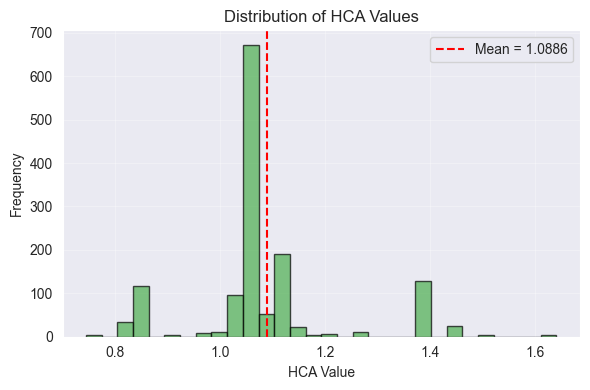

In [13]:
print(valid_df["theta_game"].describe())
HCA= valid_df["theta_game"]
plt.figure(figsize=(6, 4))
plt.hist(HCA, bins=30, color="#4CAF50", alpha=0.7, edgecolor="black")
plt.axvline(HCA.mean(), color="red", linestyle="--", label=f"Mean = {HCA.mean():.4f}")
plt.title("Distribution of HCA Values")
plt.xlabel("HCA Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [143]:
pair_summary = (
    valid_df
    .groupby(["home_abbr", "away_abbr"], as_index=False)
    .agg(
        avg_HCA=("HCA_total", "mean"),
        avg_pred_prob_home_win=("pred_prob_home_win", "mean"),
        total_home_win=("home_win", "sum"),
        total_predicted_win=("pred_label", "sum"),
        total_games=("pred_label", "count")
    )
)

# Complementary counts
pair_summary["total_predicted_lose"] = (
    pair_summary["total_games"] - pair_summary["total_predicted_win"]
)

pair_summary["pred_label"] = (
    pair_summary["avg_pred_prob_home_win"] > 0.5
).astype(int)

pair_summary.to_csv("results/1vs29_summary.csv",index=False)

## Model Comparison

### 1. Map team abbreviations to numeric indices

In [97]:
df_valid = df[df["split"] == "valid"]
teams = sorted(set(df_valid["home_abbr"]) | set(df_valid["away_abbr"]))
team_to_idx = {team: i for i, team in enumerate(teams)}
n_teams = len(teams)

print(f"{n_teams} unique teams found.")

34 unique teams found.


### 2. Prepare win–loss comparisons

In [96]:
comparisons = [
    (team_to_idx[row.home_abbr], team_to_idx[row.away_abbr])
    if row.home_win == 1 else
    (team_to_idx[row.away_abbr], team_to_idx[row.home_abbr])
    for _, row in df_valid.iterrows()
]

### 3. Fit the Bradley–Terry model

3.1 Without Home‑Court Advantage

In [98]:
bt_nohca = choix.ilsr_pairwise(n_items=n_teams, data=comparisons, alpha=0.01)

3.2 With HCA

In [100]:
home_flags = np.array([1 if row.home_win==1 else -1 for _, row in df_valid.iterrows()])

# Pairwise comparisons with context vector “home=+1 / −1”
data_with_context = []
for (i, j), flag in zip(comparisons, home_flags):
    data_with_context.append((i, j, np.array([flag], dtype=float)))

# Initialize parameter
theta_all = np.zeros(n_teams + 1)

# gradient-ascent on log-likelihood
def contextual_fit(data, n_items, step_size=1e-3, n_iter=5000):
    theta = np.zeros(n_items + 1)
    for _ in range(n_iter):
        grad = np.zeros_like(theta)
        for winner, loser, x in data:
            logit = (theta[winner] - theta[loser]) + np.dot(theta[n_items:], x)
            p = expit(logit)
            grad[winner] += (1 - p)
            grad[loser]  -= (1 - p)
            grad[n_items:] += (1 - p) * x
        theta += step_size * grad
    return theta

theta_all = contextual_fit(data_with_context, n_teams)
bt_hca = theta_all[:-1]
log_theta = theta_all[-1]
theta = np.exp(log_theta)
print(f"Estimated home‑court multiplier θ = {theta:.4f}")

Estimated home‑court multiplier θ = 1.2584


### Model Performance

In [103]:
def predict_prob(df, ability, theta=1):
    probs = []
    for r in df.itertuples(index=False):
        i = team_to_idx[r.home_abbr]
        j = team_to_idx[r.away_abbr]
        p = (theta * np.exp(ability[i])) / (theta * np.exp(ability[i]) + np.exp(ability[j]))
        probs.append(p)
    return np.array(probs)

p_nohca = predict_prob(df_valid, bt_nohca)
p_hca   = predict_prob(df_valid, bt_hca, theta)

ll_nohca = log_loss(df_valid.home_win, p_nohca)
ll_hca   = log_loss(df_valid.home_win, p_hca)
acc_nohca = accuracy_score(df_valid.home_win, p_nohca > 0.5)
acc_hca   = accuracy_score(df_valid.home_win, p_hca > 0.5)

print(f"No HCA → logloss  {ll_nohca:.4f}, acc {acc_nohca:.4f}")
print(f"With HCA → logloss {ll_hca:.4f}, acc {acc_hca:.4f}")

No HCA → logloss  0.5961, acc 0.6881
With HCA → logloss 0.5906, acc 0.6945


In [105]:
# --- Compute predictions for both models ---
p_nohca = predict_prob(df_valid, bt_nohca)
p_hca   = predict_prob(df_valid, bt_hca, theta)

# --- Predicted classes (0/1) ---
y_hat_nohca = (p_nohca >= 0.5).astype(int)
y_hat_hca   = (p_hca >= 0.5).astype(int)

# --- Performance metrics ---
ll_nohca = log_loss(df_valid.home_win, p_nohca)
ll_hca   = log_loss(df_valid.home_win, p_hca)
acc_nohca = accuracy_score(df_valid.home_win, y_hat_nohca)
acc_hca   = accuracy_score(df_valid.home_win, y_hat_hca)

# --- Combine outputs into a readable DataFrame ---
df_pred = df_valid.copy()
df_pred = df_pred.assign(
    prob_nohca=p_nohca,
    prob_hca=p_hca,
    pred_nohca=y_hat_nohca,
    pred_hca=y_hat_hca
)

# Show first few predictions with actual outcome and model results
cols_to_show = [
    "home_abbr", "away_abbr", "home_win",
    "prob_nohca", "prob_hca", "pred_nohca", "pred_hca"
]
print("\nSample predictions:")
print(df_pred[cols_to_show].to_string(index=False))


Sample predictions:
home_abbr away_abbr  home_win  prob_nohca  prob_hca  pred_nohca  pred_hca
      OKC       IND         1    0.696299  0.748967           1         1
      IND       OKC         1    0.303701  0.346733           0         0
      OKC       IND         1    0.696299  0.748967           1         1
      IND       OKC         0    0.303701  0.346733           0         0
      IND       OKC         1    0.303701  0.346733           0         0
      OKC       IND         1    0.696299  0.748967           1         1
      OKC       IND         0    0.696299  0.748967           1         1
      IND       NYK         1    0.523115  0.583218           1         1
      NYK       IND         1    0.476885  0.530881           0         1
      OKC       MIN         1    0.720601  0.770904           1         1
      IND       NYK         1    0.523115  0.583218           1         1
      MIN       OKC         0    0.279399  0.320006           0         0
      IND       N

In [125]:
print(df[df["split"] == "train"][model.context_cols].mean())
print(df[df["split"] == "valid"][model.context_cols].mean())
val_theta = np.exp(model.alpha_hca + HCA.mean())
print(f"Validation home‑court multiplier θ_val = {val_theta:.3f}")

home_b2b          0.122562
away_b2b          0.223212
home_rest_days    1.311386
away_rest_days    1.167331
rest_diff         0.144789
dtype: float64
home_b2b          0.160600
away_b2b          0.169165
home_rest_days    1.284797
away_rest_days    1.217702
rest_diff         0.066381
dtype: float64
Validation home‑court multiplier θ_val = 1.081
